## Descriptive statistics and Exploratory Data Analysis

In real world applications, the distributions and parameters of random variables are rarely known. Instead, we must determine reasonable forms and values from a data set.

A first approach is to visualize the data set. In order to be able to find a reasonable distribution to use, we have to be able to identify distributions.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
rng = np.random.default_rng(seed=42)
def histogram(X, bins=None):
    plt.hist(X, bins=bins)   

def ogive(X, bins=None):
    plt.hist(X, cumulative=True, bins=bins)   

The simplest discrete distribution is the Bernoulli, or two-point, distribution.

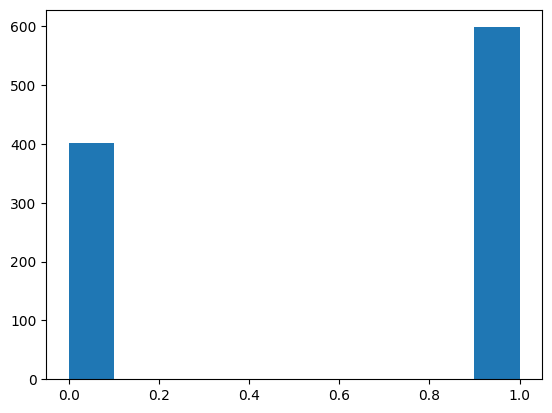

In [2]:
X = rng.choice([0,1], size=1000,p=[0.4, 0.6])
histogram(X)

Below is a geometric distribution. The only parameter is $p$, the probability of success on each Bernoulli trial. Note that even though the probability of success is about a third, there was one experiment that took twenty trials to succeed!

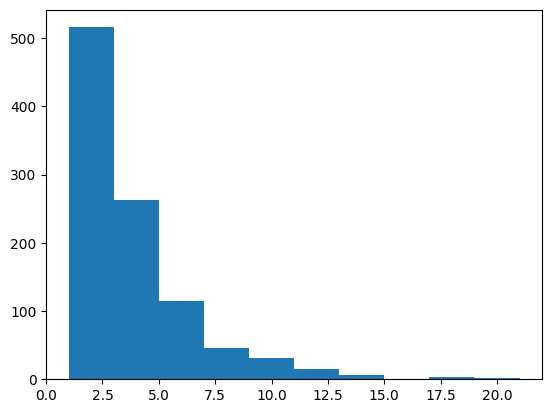

In [3]:
X = rng.geometric(p=0.31, size=1000)
histogram(X)

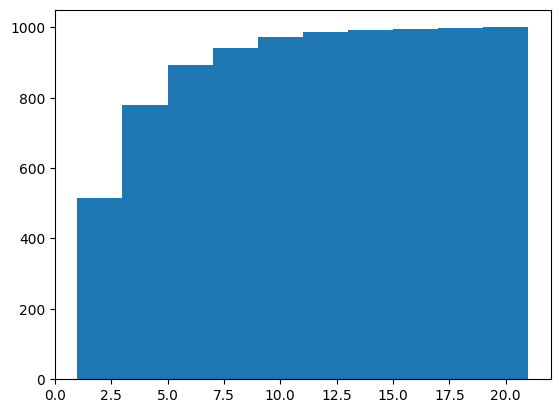

In [4]:
ogive(X)

The binomial and negative binomial distributions can be difficult to tell apart unless $n$ is large and the sample sizes are also large. In general, the binomal is centered while the negative binomial tends to have a tail on the right and the hump towards the left of the median, but here the thrid and fourth moments (skew and kurtosis) come in to play. Look for the hump and tail if you suspect it's a negative binomial. Changing the number of bins can sometimes help! However, ultimately _likelihood_ tests are the best way to tell them apart in machine learning, where we only have noisy and incomplete data to work with. By _maximizing_ the likelihood, we end up choosing the most probably distribution for all the data. More on this at the end of the course!

For now, let's look at the distributions in histograms, for a fairly large number of trials (100) in one thousand experiments.

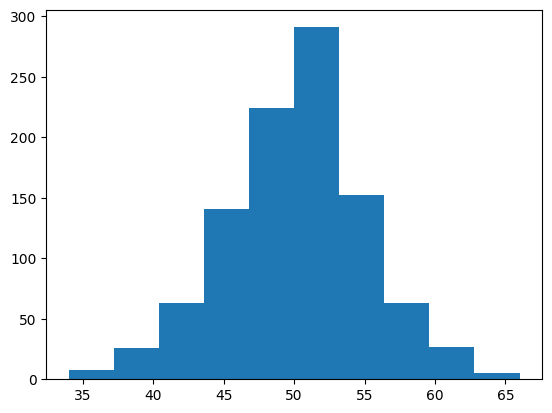

In [5]:
X = rng.binomial(n=100,p=.5,size=1000)
histogram(X)

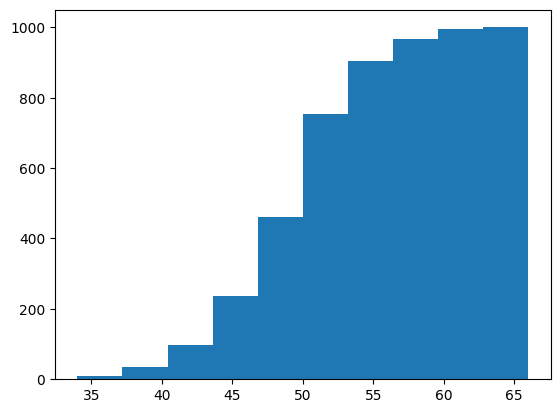

In [6]:
ogive(X)

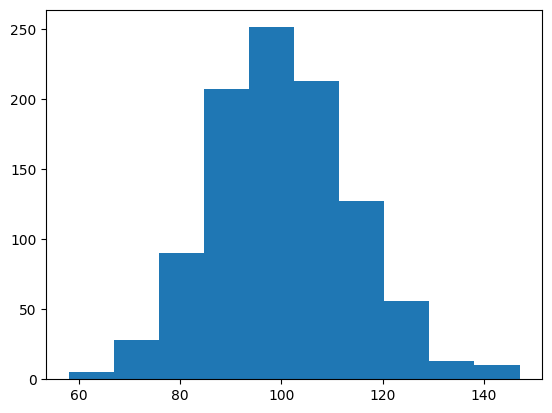

In [7]:
X = rng.negative_binomial(n=100,p=.5,size=1000)
histogram(X)

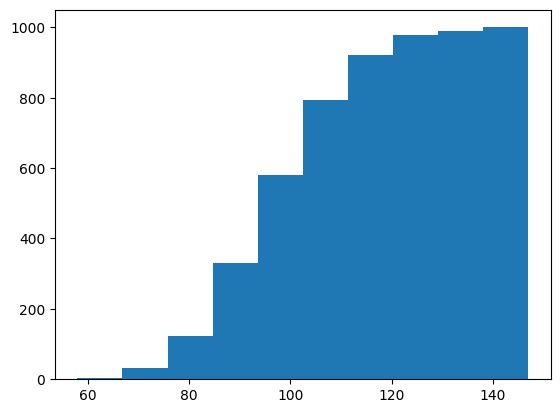

In [8]:
ogive(X)

It's hard to see, but there is a slight skew and kurtosis on the negative binomial. The tail is on the right, hump on the left; this is known as a _right skew_. The size and shape of the tail is the kurtosis moment. Also note that the CDF increases faster.

In a histogram for large samples and many trials $n$ it is practically impossible to tell a binomial distribution from a normal distribution. One clue is to look at the values -- a binomial has larger positive values, while a normal and standard normal have smaller negative and positive values (compared to the mean). 

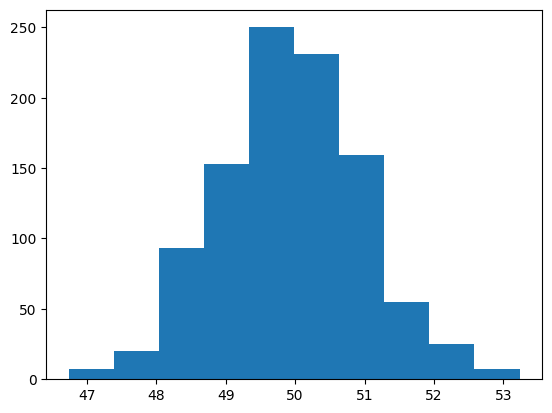

In [9]:
X = rng.normal(size=1000,loc=50)
histogram(X)

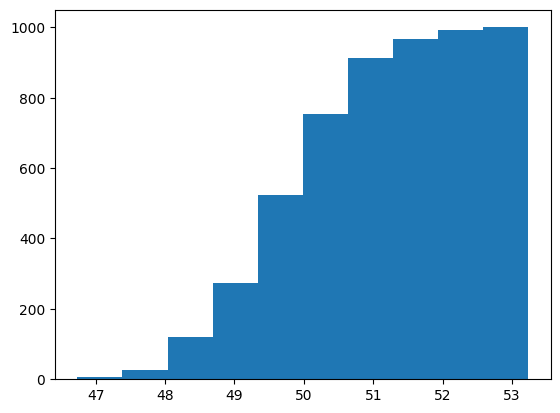

In [10]:
ogive(X)

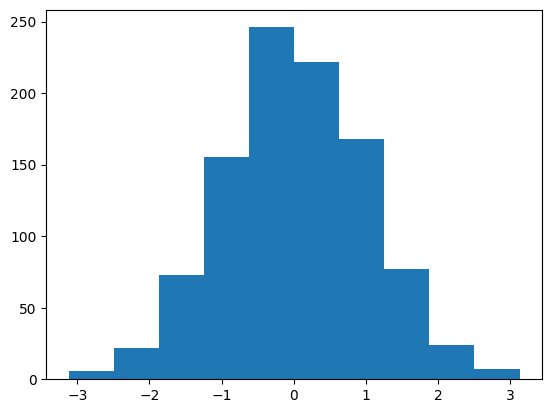

In [11]:
X = rng.standard_normal(size=1000)
histogram(X)

Now lets look at some data!

In [12]:
import pandas as pd

df = pd.read_csv("../Data/Advertising.csv", index_col=0)
df.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


Here, the Sales column is the result and the other columns are how much has been spent on each form of advertising. 


### Exercise 1

a) Make a histogram and/or ogive of the Sales column. Try to reason about what kind of distribution this is. Is there some known stochastic process or do you have to make some generic assumption?

b) Can you think of some mathematical method to figure out which distribution is most _alike_? (don't go too hard on trying to implement this one, it will probably be very frustrating)

b) Make a boxplot and comment on which plot you prefer (for whatever reason). 

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
sales = df["Sales"].dropna()
n = len(sales)

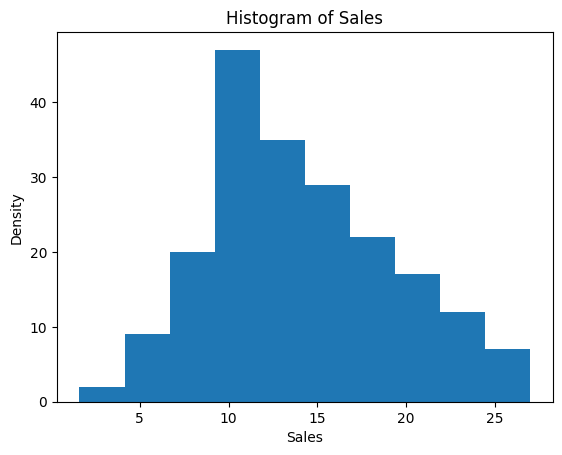

In [15]:
# a)
plt.figure()
plt.hist(sales)
plt.title("Histogram of Sales")
plt.xlabel("Sales")
plt.ylabel("Density")
plt.show()

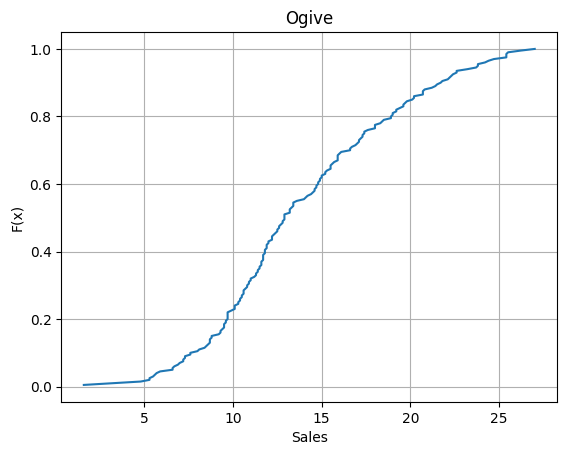

In [16]:
x_sorted = np.sort(sales)
y = np.arange(1, n+1) / n 

plt.figure()
plt.plot(x_sorted, y)
plt.title("Ogive")
plt.xlabel("Sales")
plt.ylabel("F(x)")
plt.grid(True)
plt.show()

In [ ]:
# b)

import scipy.stats as st

# Fit Normal
mu, sigma = st.norm.fit(sales)

# Fit Lognormal
shape, loc, scale = st.lognorm.fit(sales, floc=0)

# Fit Gamma
a, loc_g, scale_g = st.gamma.fit(sales, floc=0)

# KS test 
ks_norm = st.kstest(sales, 'norm', args=(mu, sigma))
ks_logn = st.kstest(sales, 'lognorm', args=(shape, loc, scale))
ks_gam = st.kstest(sales, 'gamma', args=(a, loc_g, scale_g))

ks_norm, ks_logn, ks_gam

(KstestResult(statistic=np.float64(0.09538258324761706), pvalue=np.float64(0.04914112083630506), statistic_location=np.float64(12.9), statistic_sign=np.int8(1)),
 KstestResult(statistic=np.float64(0.054654992392170504), pvalue=np.float64(0.569725761264043), statistic_location=np.float64(9.5), statistic_sign=np.int8(-1)),
 KstestResult(statistic=np.float64(0.04287963754665203), pvalue=np.float64(0.8400244262960435), statistic_location=np.float64(12.9), statistic_sign=np.int8(1)))

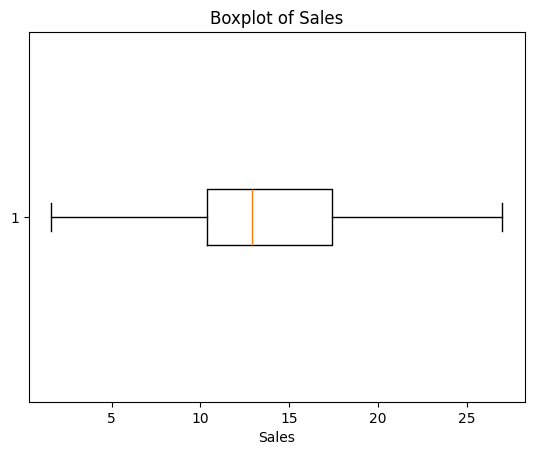

In [ ]:
# c)

plt.figure()
plt.boxplot(sales, vert=False)
plt.title("Boxplot of Sales")
plt.xlabel("Sales")
plt.show()

### Exercise 2
Produce scatter-plots of TV against Sales.

a) Can you identify some trend visually?

b) How could you test for such a trend? Tip: check out cov and corr in pandas DataFrame class

c) Can you motivate your findings with mathematical statistics?

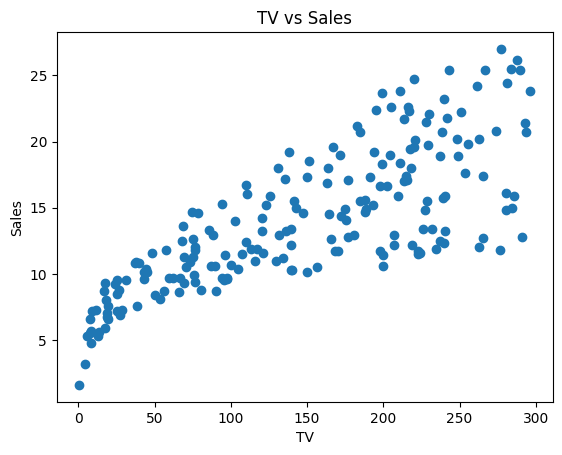

In [20]:
# a)
plt.figure()
plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV")
plt.ylabel("Sales")
plt.title("TV vs Sales")
plt.show()

In [21]:
# b)
cov_tv_sales = df["TV"].cov(df["Sales"])
corr_tv_sales = df["TV"].corr(df["Sales"])

cov_tv_sales, corr_tv_sales

(np.float64(350.3901947236182), np.float64(0.7822244248616066))

In [ ]:
# c)
import statsmodels.api as sm

X = df["TV"]
y = df["Sales"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Mon, 02 Feb 2026   Prob (F-statistic):           1.47e-42
Time:                        10:21:24   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0326      0.458     15.360      0.0

### Exercise 3

Use the same method from exercise 2 and investigate Radio and Newspaper.

Answer the same questions, where appropriate, for these other two variables.


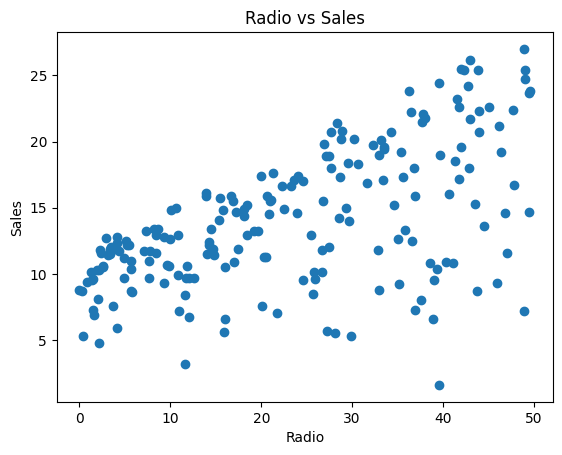

In [24]:
# a)
# Radio vs Sales

plt.scatter(df["Radio"], df["Sales"])
plt.xlabel("Radio")
plt.ylabel("Sales")
plt.title("Radio vs Sales")
plt.show()

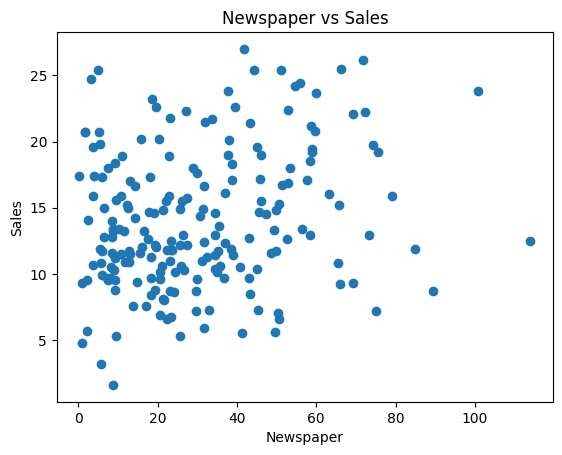

In [25]:
# a)
# Newspaper vs Sales

plt.scatter(df["Newspaper"], df["Sales"])
plt.xlabel("Newspaper")
plt.ylabel("Sales")
plt.title("Newspaper vs Sales")
plt.show()

In [ ]:
# b) 
# Radio

cov_radio = df["Radio"].cov(df["Sales"])
corr_radio = df["Radio"].corr(df["Sales"])

cov_radio, corr_radio

(np.float64(44.635688442211055), np.float64(0.5762225745710553))

Det finns ett tydligt positivt samband mellan Radio och Sales.
Korrelationskoefficien är cirka 0.58, vilket indikerar ett måttligt starkt samband.

In [27]:
# b)
# Newspaper

cov_news = df["Newspaper"].cov(df["Sales"])
corr_news = df["Newspaper"].corr(df["Sales"])

cov_news, corr_news

(np.float64(25.941391959799002), np.float64(0.22829902637616534))

Sambandet mellan Newspaper och Sales  är svagt.
Korrelationskoefficienten är låg (cirka 0.23), vilket tyder på att Newspaper har liten påverkan på Sales.

#### Exercise 4

There are a lot of statistics computed automatically by pandas and numpy. 

Run the command <code> df.describe() </code>

Refer to the lecture notes and book to describe what the output of the command means.

a) How is the mean computed? Verify the value by computing it directly on your own.

b) How is the standard deviation computed? Verify the value as above.

c) What is the meaning of the remaining values?

In [29]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [ ]:
# a)
df["Sales"].mean()

np.float64(14.0225)

Medelvärdet beräknas som summan av alla observationer dividerat med antalet observationer.
Värdet kan veriferas genom att använda mean()-funktionen direkt.

In [30]:
# b)
df["Sales"].std()

np.float64(5.217456565710478)

Standardavvikelsen mäter spridningen kring medelvärdet och beräknas som kvadratroten av variansen.
Värdet verifieras genom att använda std()-funktionen.

In [31]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


Count anger antalet observationer.
Min och max visar det minsta respektive största värdet.
25%, 50% och 75% representerar kvartilerna, där 50% är medianen.

### Exercise 5

Far from all usual statistics are computed by <code>describe()</code>, but they are easily available in pandas.

a) Find a function in pandas and use it to compute the median and mode of the columns in the dataframe. How do those location statistics compare to the mean?

b) Verify whether pandas uses _Bessel's correction_ for the sample variance. Compute it on your own and compare with what pandas reports. Why is Bessel's correction used at all?

In [38]:
df.median()

TV           149.75
Radio         22.90
Newspaper     25.75
Sales         12.90
dtype: float64

In [37]:
df.mode()

,TV,Radio,Newspaper,Sales
0,17.2,4.1,8.7,9.7
1,76.4,5.7,9.3,NaN
2,109.8,NaN,25.6,NaN
3,177.0,NaN,NaN,NaN
4,184.9,NaN,NaN,NaN
5,197.6,NaN,NaN,NaN
6,199.8,NaN,NaN,NaN
7,222.4,NaN,NaN,NaN
8,237.4,NaN,NaN,NaN
9,240.1,NaN,NaN,NaN


In [36]:
df.mean()

TV           147.0425
Radio         23.2640
Newspaper     30.5540
Sales         14.0225
dtype: float64

Medianen (median) är mittvärdet när observationerna sorteras.
Typvärdet (Modus) är det/de värde(n) som förekommer oftas.
Medelvärdet (Mean) är summan av observationerna dividerat med antalet.

Jämförelse:
- Om fördelningen är ungefär symmetrisk blir mean och median oftas nära varandra.
- Om fördelningen är sned (t.ex. högerskev) dras mean mot svansen, medan medianen är mer robust mot extremvärden. 
- Modus kan skilja sig mycket och kan vara flera värden.

In [39]:
# b)
col = "Sales"

var_pandas = df[col].var()
var_ddof0 = df[col].var(ddof=0)
var_ddof1 = df[col].var(ddof=1)

var_pandas, var_ddof0, var_ddof1

(np.float64(27.22185301507538),
 np.float64(27.085743750000002),
 np.float64(27.22185301507538))

In [40]:
x = df[col].dropna().to_numpy()
n = len(x)
xbar = x.mean()

s2 = np.sum((x - xbar)**2) / (n - 1)
sigma2 = np.sum((x - xbar)**2) / n

s2, sigma2

(np.float64(27.22185301507538), np.float64(27.085743750000002))

Pandas använder som standard Bassel-korrektionen för stickprovsvarians, dvs. den delar med (n-1) (ddof=1).
Det kan verifieras genom att jämföra df[col].var() med df[col].var(ddof=1).

Bassel-korrektionen används eftersom variansen annars tenderar att underskattas när man skattar populationsvariansen från ett stickprov.
Genom att dela med (n-1) fär man en obiaserad skattning av populationsvariansen.